# Legendre Polynomials and $A^{(k)}$ computation

In [3]:
import sympy as sp

# Legendre polynomial generator (unused in main flow but kept for completeness)
x = sp.symbols('x')
def Legendre(n):
    """Generates Legendre polynomials up to degree n using recurrence relation"""
    if n == 0:
        return [1]
    if n == 1:
        return [1,x]
    sol = [1,x]
    for i in range(2,n+1):
        temp = sp.expand(sp.Rational(2*i-1,i)*sol[i-1]*x - sp.Rational(i-1,i)*sol[i-2])
        sol.append(temp)
    return sol

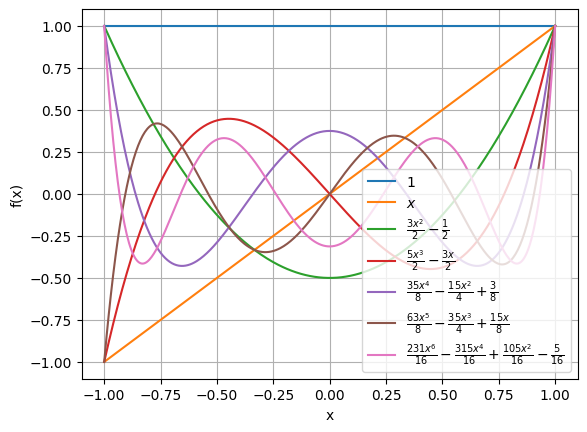

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

x = sp.symbols('x')
pols = Legendre(6)

x_vals = np.linspace(-1, 1, 400)

for i in range(0, len(pols)):
    if i==0:
        y_vals = [1 for i in range (0,400)]
    else:
        f = sp.lambdify(x, pols[i], 'numpy')
        y_vals = f(x_vals)
    plt.plot(x_vals, y_vals, label=f"${sp.latex(pols[i])}$")
    plt.xlabel('x')
    plt.ylabel('f(x)')


plt.grid(True)
plt.legend()
plt.show()



0.11547005383792516
0.8
1.2


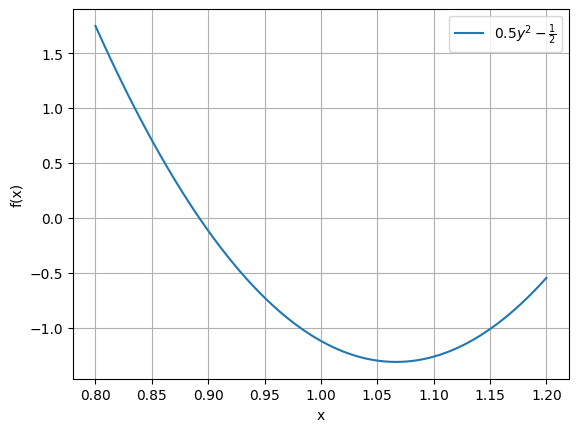

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import math

x, y = sp.symbols('x y')

pols = np.array(Legendre(2))
poly=[1]

for i in range (1,len(pols)):
    poly.append(pols[i].subs({x: y/math.sqrt(3)}))

mu = 1
sigma = 0.2/math.sqrt(3)
print(sigma)
l = math.sqrt(3)*sigma
a = mu - l
b = mu + l
print(a)
print(b)

poly = np.array(poly)

c = [-0.546107361811860, -1.14696132364056, 1.14730115938622]
sol = c @ poly.T

sol = sol.subs({y: math.sqrt(3)*(y-mu)/(l)})
x_vals = np.linspace(a, b, 400)

f = sp.lambdify(y, sol, 'numpy')
y_vals = f(x_vals)
plt.plot(x_vals, y_vals, label=f"${sp.latex(poly[i])}$")
plt.xlabel('x')
plt.ylabel('f(x)')


plt.grid(True)
plt.legend()
plt.show()


In [6]:
pip install sympy.physics

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement sympy.physics (from versions: none)
ERROR: No matching distribution found for sympy.physics


In [7]:
from sympy.physics.wigner import wigner_3j
import sympy

ell1, ell2, ell3 = 2, 1, 1
symbol = sympy.physics.wigner.wigner_3j(ell1, ell2, ell3, 0, 0, 0)

# Esempio di utilizzo:
N_PC = 6
N = N_PC+1
for i in range (0,N):
    A = [[0 for m in range (0,N)] for n in range (0,N)]
    for j in range (0,N):
        for k in range (0,N):
            symbol = sympy.physics.wigner.wigner_3j(i, j, k, 0, 0, 0)
            A[j][k] = 2*((symbol)**2)
    A = np.matrix(A)
    print(A)



[[2 0 0 0 0 0 0]
 [0 2/3 0 0 0 0 0]
 [0 0 2/5 0 0 0 0]
 [0 0 0 2/7 0 0 0]
 [0 0 0 0 2/9 0 0]
 [0 0 0 0 0 2/11 0]
 [0 0 0 0 0 0 2/13]]
[[0 2/3 0 0 0 0 0]
 [2/3 0 4/15 0 0 0 0]
 [0 4/15 0 6/35 0 0 0]
 [0 0 6/35 0 8/63 0 0]
 [0 0 0 8/63 0 10/99 0]
 [0 0 0 0 10/99 0 12/143]
 [0 0 0 0 0 12/143 0]]
[[0 0 2/5 0 0 0 0]
 [0 4/15 0 6/35 0 0 0]
 [2/5 0 4/35 0 4/35 0 0]
 [0 6/35 0 8/105 0 20/231 0]
 [0 0 4/35 0 40/693 0 10/143]
 [0 0 0 20/231 0 20/429 0]
 [0 0 0 0 10/143 0 28/715]]
[[0 0 0 2/7 0 0 0]
 [0 0 6/35 0 8/63 0 0]
 [0 6/35 0 8/105 0 20/231 0]
 [2/7 0 8/105 0 4/77 0 200/3003]
 [0 8/63 0 4/77 0 40/1001 0]
 [0 0 20/231 0 40/1001 0 14/429]
 [0 0 0 200/3003 0 14/429 0]]
[[0 0 0 0 2/9 0 0]
 [0 0 0 8/63 0 10/99 0]
 [0 0 4/35 0 40/693 0 10/143]
 [0 8/63 0 4/77 0 40/1001 0]
 [2/9 0 40/693 0 36/1001 0 40/1287]
 [0 10/99 0 40/1001 0 4/143 0]
 [0 0 10/143 0 40/1287 0 56/2431]]
[[0 0 0 0 0 2/11 0]
 [0 0 0 0 10/99 0 12/143]
 [0 0 0 20/231 0 20/429 0]
 [0 0 20/231 0 40/1001 0 14/429]
 [0 10/99 0 40/1001